# **Diferencias finitas.**
Dada la ecuación diferencial:

$$
\frac{du}{dt} = u \quad \text{con} \quad u(0) = 1
$$

y la condición: $dt = 0'2$

Se pide:

1. Encontrar la solución general $u(t)$ de la ecuación diferencial.
2. Verificar que la solución $u(t) = e^t $ satisface la ecuación diferencial y la condición inicial.
3. Calcular los valores de $u(t)$ para $t = 0, t = 0^2, t = 0^4, t = 0^6, \ldots$ y completar la secuencia: $u(t) = [1, \ldots]$

4. Utilizar el método de diferencias finitas para aproximar la solución:

$$
\frac{u_{t+dt} - u_t}{dt} = u_t \quad \text{con} \quad u_{t+dt} = u_t dt
$$

**Nota:** Asegúrate de justificar cada paso y verificar los resultados obtenidos.

## **Definición de las funciones: Basado en el método de Euler.**
Implemente una función en Python que calcule la solución de una ecuación diferencial ordinaria del tipo:

$$
\frac{dx}{dt} = f(x, t)
$$

dónde $t \in [t_0, t_f]$ y con la condición inicial $ x(t_0) = x_0 $ siendo $ x_0 $ una constante, utilizando el método de Euler. La función debe aceptar como variables a $f(x, t), t_0, t_f, x_0, N$ siendo N el número de pasos.

In [18]:
import numpy as np
import matplotlib.pyplot as plt

In [19]:
def euler(f, t0, tn, y0, N):
    h = (tn - t0) / N
    t = np.linspace(t0, tn, N+1)
    y = [y0]

    for i in range(N):
        y.append(y[i] + h * f(t[i], y[i]))

    return y, t

In [20]:
def euler2(f, t0, tn, y0, h):
    N = int((tn - t0) / h) #no puede ser tipo float.
    t = np.linspace(t0, tn, N+1)
    y = [y0]
    
    for i in range(N):
        y.append(y[i] + h * f(t[i], y[i]))
    
    return y, t

### **Planteamiento del ejercicio.**

In [21]:
def f(t, u):
    return u

In [22]:
# Solución analítica u(t) = e^t.
t_exact = np.linspace(0, 4, 100)
u_exact = np.exp(t_exact)

In [23]:
# Solución numérica con método de Euler.
t0, tn, y0 = 0, 4, 1
dt_values = [0.2, 0.04]  # Valores de dt a comparar.
solutions = [euler2(f, t0, tn, y0, dt) for dt in dt_values]

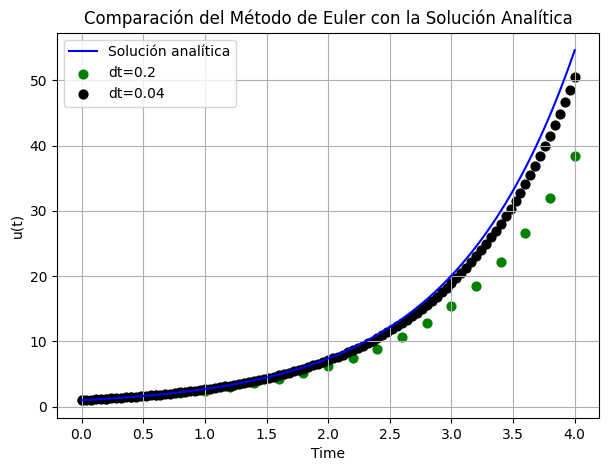

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(t_exact, u_exact, label="Solución analítica", color="blue")

colors = ["green", "black"]
for i, (u_euler, t_euler) in enumerate(solutions):
    plt.scatter(t_euler, u_euler, label=f"dt={dt_values[i]}", marker='o', s=40, color=colors[i])

plt.xlabel("Time")
plt.ylabel("u(t)")
plt.legend()
plt.grid()
plt.title("Solución Numérica usando Diferencias Finitas")
plt.show()

## **Diferencias Finitas y A-Estabilidad.**
Considera la siguiente ecuación diferencial ordinaria con condiciones de borde:

$$
\frac{d^2 u}{dx^2} = 10; \quad u(0) = 0; \quad u(1) = 3
$$

1. **Discretización del problema**:
   - Aplica el método de diferencias finitas para discretizar la ecuación diferencial en un mallado con $N = 5$ puntos interiores (es decir, $\Delta x = \frac{1}{6}$).
   - Escribe el sistema de ecuaciones en forma matricial $Au = B$, dónde $A$ es la matriz de coeficientes, $u$ es el vector de incógnitas y $B$ es el vector de términos independientes.

2. **Solución analítica**: Encuentra la solución analítica de la ecuación diferencial y compárala con la solución numérica obtenida.

3. **A-Estabilidad**: Discute si el método de diferencias finitas utilizado es **A-Estable** y por qué.

### **Definición de las funciones.**

1. **Ecuación Diferencial y Condiciones de Frontera:** La ecuación diferencial que se quiere resolver es:
$$
\frac{d^2 u}{dx^2} = g(x)
$$
con las condiciones de frontera: $u(x_i) = u_0 \text{ y } u(x_f) = u_f$. Aquí, $g(x)$ es una función conocida que representa el término no homogéneo de la ecuación diferencial.

2. **Discretización del Dominio:** El dominio $[x_i, x_f]$ se discretiza en $N + 2$ puntos, incluyendo los extremos. El espaciado $\Delta x$ entre los puntos se calcula como:

$$
\Delta x = \frac{x_f - x_i}{N + 1}
$$

Los puntos en el dominio discretizado son: $x_j = x_i + j \cdot \Delta x \quad \text{para} \quad j = 0, 1, 2, \ldots, N + 1$ dónde $x_0 = x_i$ y $x_{N+1} = x_f$ son los puntos de frontera.

3. **Aproximación de la Segunda Derivada:** La segunda derivada de $u$ en un punto $x_j$ se aproxima utilizando diferencias finitas. La aproximación más común es:

$$
\frac{d^2 u}{dx^2} \bigg|_{x_j} \approx \frac{u_{j+1} - 2u_j + u_{j-1}}{\Delta x^2}
$$

dónde $u_j$ representa el valor de $u$ en el punto $x_j$.

4. **Sistema de Ecuaciones Lineales:** Al sustituir la aproximación de la segunda derivada en la ecuación diferencial, se obtiene una ecuación para cada punto interior $x_j$:

$$
\frac{u_{j+1} - 2u_j + u_{j-1}}{\Delta x^2} = g(x_j)
$$

Esto da lugar a un sistema de $N$ ecuaciones lineales con $N$ incógnitas (los valores de $u$ en los puntos interiores). Las condiciones de frontera $u(x_i) = u_0$ y $u(x_f) = u_f$ se utilizan para ajustar las ecuaciones en los puntos cercanos a los extremos.

5. **Matriz del Sistema:** El sistema de ecuaciones se puede expresar en forma matricial como:
$$
A \cdot \mathbf{u} = \mathbf{B}
$$

dónde:
- $A$ es una matriz tridiagonal que contiene los coeficientes de las ecuaciones.
- $\mathbf{u}$ es el vector de incógnitas (los valores de $u$ en los puntos interiores).
- $\mathbf{B}$ es el vector del lado derecho, que incluye los términos independientes y las contribuciones de las condiciones de frontera.

La matriz $A$ se construye como:

$$
A = \frac{1}{\Delta x^2} \begin{bmatrix}
\Delta x^2 & 1 & 0 & \cdots & 0 \\
1 & -2 & 1 & \cdots & 0 \\
0 & 1 & -2 & \cdots & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
0 & 0 & 0 & \cdots & \Delta x^2 \\
\end{bmatrix}
$$

6. **Vector del Lado Derecho:** El vector $\mathbf{B}$ se construye evaluando la función $g(x)$ en los puntos interiores y ajustando por las condiciones de frontera:

$$
B_j = g(x_j) \quad \text{para} \quad j = 1, 2, \ldots, N
$$

con los ajustes:

$$
B_1 = g(x_1) - \frac{u_0}{\Delta x^2} \quad \text{y} \quad B_N = g(x_N) - \frac{u_f}{\Delta x^2}
$$


Una vez resuelto el sistema, se obtienen los valores de $u$ en los puntos interiores. Estos valores, junto con las condiciones de frontera, permiten construir la solución numérica $u(x)$ en todo el dominio discretizado.

In [ ]:
def diferencias_finitas(N, g, xi, xf, u0, uf):
    """
    Parámetros:
    - N: Número de puntos internos en el mallado
    - g: Función del lado derecho de la ecuación diferencial d^2u/dx^2 = g(x)
    - xi: Límite inferior del dominio
    - xf: Límite superior del dominio
    - u0: Condición de frontera en x = xi
    - uf: Condición de frontera en x = xf
    """

    dx = (xf - xi) / (N + 1)  # Espaciado de la malla.
    x = np.linspace(xi, xf, N + 2)  # Incluye los puntos de frontera.

    # Construcción sistema: A*u = B.
    ## Matriz A.
    A = np.eye(N, k=-1) + np.eye(N, k=1) - 2 * np.eye(N)
    A /= dx**2

    ## Vector B.
    B = np.array([g(xi + (i + 1) * dx) for i in range(N)])
    B[0] -= u0 / dx**2  # u(xi) = u0
    B[-1] -= uf / dx**2  # u(xf) = uf

    u_interior = np.linalg.solve(A, B)

    # Agregamos las condiciones de frontera.
    u = np.concatenate(([u0], u_interior, [uf]))

    return x, u # x: Puntos en el espacio discretizado; u: Solución numérica obtenida.

### **Planteamiento del ejercicio.**

In [28]:
def g(x):
    return 5

# Parámetros
N, xi, xf, u0, uf  = 30, 0, 1, 1, 2
x, u_num = diferencias_finitas(N, g, xi, xf, u0, uf)
u_exact = (5/2) * x**2 - (3/2) * x + 1

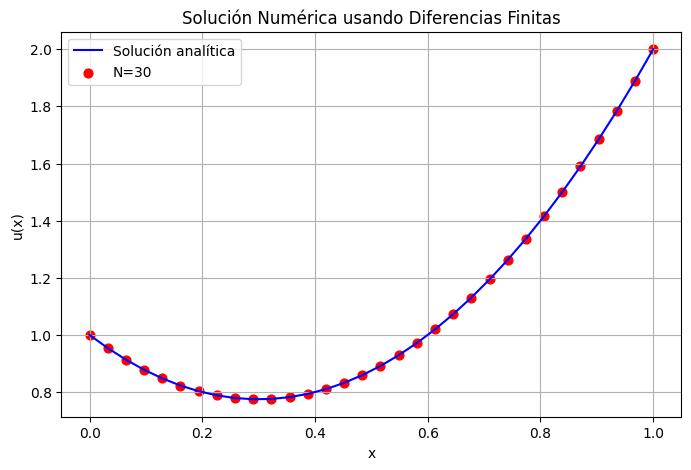

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(x, u_exact, label="Solución analítica", color="blue")
plt.scatter(x, u_num, label=f"N={N}", color="red", marker="o", s=40)
plt.xlabel("x")
plt.ylabel("u(x)")
plt.legend()
plt.grid()
plt.title("Solución Numérica usando Diferencias Finitas")
plt.show()

### **Otro ejemplo.**
La distribución del potencial eléctrico $V(x)$ en una barra de varias aleaciones metálicas de 1 metro de longitud está descrita por la siguiente ecuación diferencial:

$$
\frac{d^2V}{dx^2} + 2\frac{dV}{dx} - 0.5(V_0 - V) = 0
$$

dónde:
- $V_0 = 10$ es un valor de referencia del potencial.
- $V(0) = 50$ es el potencial en el extremo izquierdo de la barra ($x = 0$).
- $V(1) = 0$ es el potencial en el extremo derecho de la barra ($x = 1$).

Se pide:

1. **Discretización del problema**:
   - Aplica el método de diferencias finitas para discretizar la ecuación diferencial en un mallado con $N$ puntos interiores.
   - Escribe el sistema de ecuaciones en forma matricial $A \cdot \mathbf{V} = \mathbf{B}$, donde $A$ es la matriz de coeficientes, $\mathbf{V}$ es el vector de incógnitas (potenciales en los puntos interiores), y $\mathbf{B}$ es el vector de términos independientes.

2. **Resolución numérica**:
   - Resuelve el sistema de ecuaciones lineales para obtener los valores del potencial $V(x)$ en los puntos interiores de la barra.
   - Utiliza $N = 10$ y $N=500$ para la discretización.

3. **Gráfica de la solución**:
   - Grafica la distribución del potencial eléctrico $V(x)$ en función de la posición $x$ a lo largo de la barra.
   - Incluye en la gráfica los puntos de frontera $V(0) = 50$ y $V(1) = 0$.

4. **Análisis de resultados**:
   - Discute cómo varía el potencial eléctrico a lo largo de la barra.
   - Compara la solución numérica con una solución analítica si es posible, o analiza la convergencia del método para diferentes valores de $N$.

In [36]:
def diferencias_finitas_primer_orden(N, V0=10, xi=0, xf=1, Vxi=50, Vxf=0):
    """
    Parámetros:
    N: Número de puntos internos en el mallado (sin contar los extremos)
    V0: Valor de referencia en la ecuación diferencial (dado en el problema)
    xi: Límite inferior del dominio (por defecto 0)
    xf: Límite superior del dominio (por defecto 1)
    Vxi: Condición de frontera en x = xi
    Vxf: Condición de frontera en x = xf
    """
    dx = (xf - xi) / (N + 1)
    x = np.linspace(xi, xf, N + 2)

    A = np.eye(N, k=-1) * (1/dx**2 - 1/dx) + np.eye(N, k=1) * (1/dx**2 + 1/dx) - np.eye(N) * (2/dx**2 - 0.5)
    B = np.full(N, 0.5 * V0)
    B[0] -= (1/dx**2 - 1/dx) * Vxi
    B[-1] -= (1/dx**2 + 1/dx) * Vxf

    V_interior = np.linalg.solve(A, B)
    V = np.concatenate(([Vxi], V_interior, [Vxf]))

    return x, V

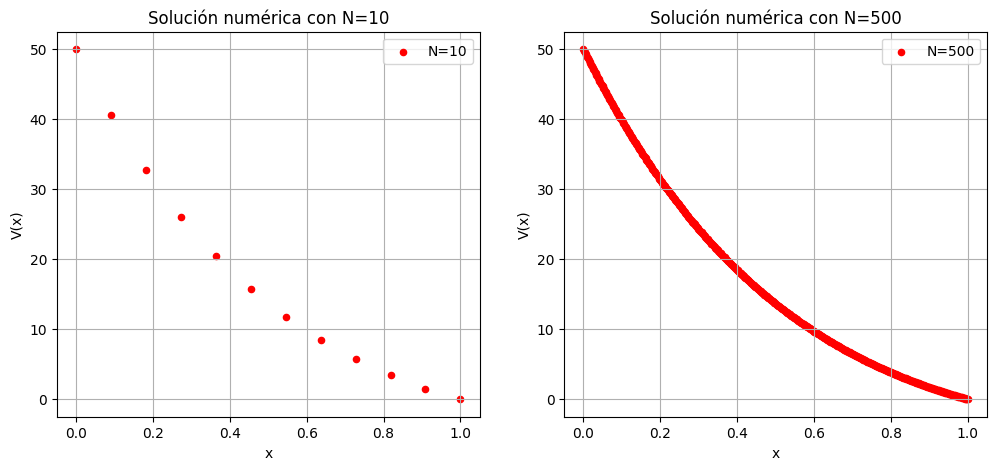

In [37]:
N_values = [10, 500]
solutions = [diferencias_finitas_primer_orden(N) for N in N_values]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, (N, (x, V_num)) in enumerate(zip(N_values, solutions)):
    axes[i].scatter(x, V_num, label=f"N={N}", color="red", marker="o", s=20)
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("V(x)")
    axes[i].legend()
    axes[i].grid()

axes[0].set_title(f"Solución numérica con N={N_values[0]}")
axes[1].set_title(f"Solución numérica con N={N_values[1]}")
plt.show()